In [2]:
import pandas as pd
%matplotlib inline
from matplotlib import pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [4]:
iris = load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [11]:
df = pd.DataFrame(iris.data , columns = iris.feature_names)


In [12]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
df_updated = df.drop(df[['sepal length (cm)' , 'sepal width (cm)']] , axis = 'columns')

In [14]:
df_updated

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


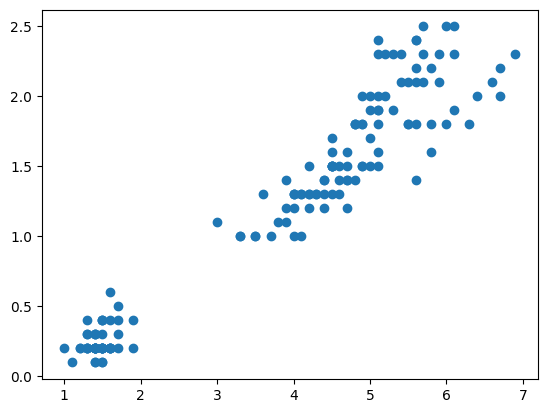

In [18]:
plt.scatter(df['petal length (cm)'],df['petal width (cm)'])


In [22]:
km = KMeans(n_clusters = 3)
km

KMeans(n_clusters=3)

In [23]:
y_predicted = km.fit_predict(df[['sepal length (cm)' , 'sepal width (cm)']])
y_predicted

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1,
       1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2], dtype=int32)

In [24]:
df_updated['cluster'] = y_predicted
df_updated.head()

,petal length (cm),petal width (cm),cluster
0,1.4,0.2,0
1,1.4,0.2,0
2,1.3,0.2,0
3,1.5,0.2,0
4,1.4,0.2,0


In [26]:
df0 = df_updated[df_updated.cluster == 0]
df1 = df_updated[df_updated.cluster == 1]
df2 = df_updated[df_updated.cluster == 2]


Text(0, 0.5, 'petal width (cm)')

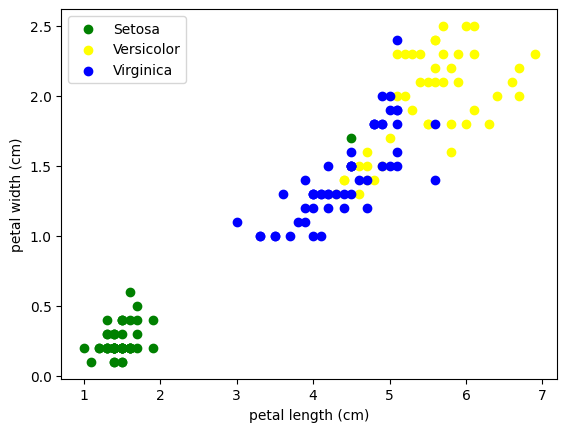

In [31]:
plt.scatter(df0['petal length (cm)'] , df0['petal width (cm)'] ,color='green' ,label='Setosa')
plt.scatter(df1['petal length (cm)'] , df1['petal width (cm)'] ,color='yellow',label='Versicolor')
plt.scatter(df2['petal length (cm)'] , df2['petal width (cm)'] ,color='blue' ,label='Virginica')

plt.legend()
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')

In [36]:
scaler = MinMaxScaler()
scaler.fit(df_updated[['petal length (cm)']])
df_updated['petal length (cm)'] = scaler.transform(df_updated[['petal length (cm)']])
df_updated

,petal length (cm),petal width (cm),cluster
0,0.067797,0.2,0
1,0.067797,0.2,0
2,0.050847,0.2,0
3,0.084746,0.2,0
4,0.067797,0.2,0
...,...,...,...
145,0.711864,2.3,1
146,0.677966,1.9,2
147,0.711864,2.0,1
148,0.745763,2.3,1


In [37]:
scaler = MinMaxScaler()
scaler.fit(df_updated[['petal width (cm)']])
df_updated['petal width (cm)'] = scaler.transform(df_updated[['petal width (cm)']])
df_updated

,petal length (cm),petal width (cm),cluster
0,0.067797,0.041667,0
1,0.067797,0.041667,0
2,0.050847,0.041667,0
3,0.084746,0.041667,0
4,0.067797,0.041667,0
...,...,...,...
145,0.711864,0.916667,1
146,0.677966,0.750000,2
147,0.711864,0.791667,1
148,0.745763,0.916667,1


In [38]:
km = KMeans(n_clusters = 3)
y_predicted = km.fit_predict(df_updated[['petal length (cm)' ,'petal width (cm)']])
df_updated['cluster'] = y_predicted
df_updated

,petal length (cm),petal width (cm),cluster
0,0.067797,0.041667,1
1,0.067797,0.041667,1
2,0.050847,0.041667,1
3,0.084746,0.041667,1
4,0.067797,0.041667,1
...,...,...,...
145,0.711864,0.916667,0
146,0.677966,0.750000,0
147,0.711864,0.791667,0
148,0.745763,0.916667,0


In [40]:
df0 = df_updated[df_updated.cluster == 0]
df1 = df_updated[df_updated.cluster == 1]
df2 = df_updated[df_updated.cluster == 2]

In [42]:
km.cluster_centers_

array([[0.7740113 , 0.81510417],
       [0.07830508, 0.06083333],
       [0.55867014, 0.51041667]])

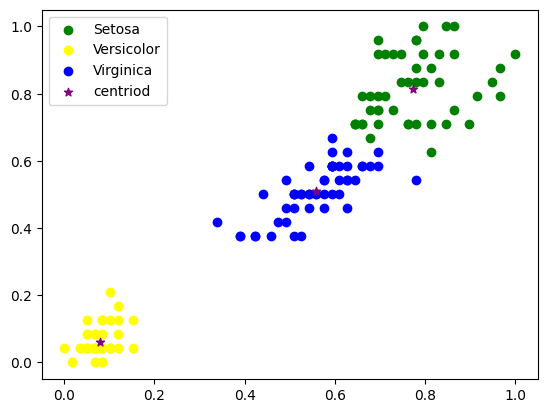

In [44]:
plt.scatter(df0['petal length (cm)'], df0['petal width (cm)'] , color = 'green' ,label='Setosa')
plt.scatter(df1['petal length (cm)'] , df1['petal width (cm)'] ,color='yellow',label='Versicolor')
plt.scatter(df2['petal length (cm)'] , df2['petal width (cm)'] ,color='blue' ,label='Virginica')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1] , color = 'purple', marker = '*',label = 'centriod')
plt.legend()
plt.show()

In [45]:
k_rng = range(1,10)
sse = []
for k in k_rng:
    km = KMeans(n_clusters = k)
    km.fit(df_updated[['petal length (cm)' ,'petal width (cm)']])
    sse.append(km.inertia_)

In [46]:
sse

[28.368353219727194,
 5.176463590044368,
 1.7018746881920963,
 1.1615234094205578,
 0.8583551942653584,
 0.7901978006193949,
 0.5955772574779121,
 0.49564647118112914,
 0.4168437623511291]

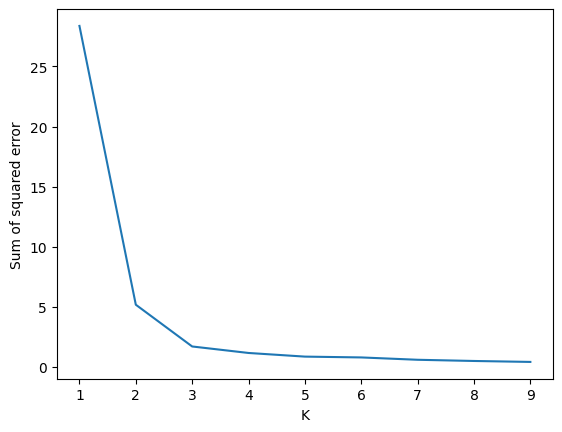

In [49]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng , sse)
# k=3 is best for KMean_Clustering